In [ ]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(os.path.join(str(abs_path_src), 'arxiv'))

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
from numpyro.handlers import seed, trace, condition
from numpyro.infer.reparam import LocScaleReparam, TransformReparam
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist

import jax 
from tqdm import tqdm
import copy


from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj
import copy
import yaml
from deepmerge import always_merger
import ast 

import dill

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov

import ast
print(sys.argv)
# probes_forecast = list(sys.argv[1])
inp_probes = "ky,kk,gg,gy,gk,ge"
probes_forecast = inp_probes.split(',')
# sc_val = int(sys.argv[2])

# probes_forecast = ['gg', 'gk']
sc_val = 4000

probes_forecast_all_str = '_'.join(probes_forecast)
run_this_script = True


/tmp/ipykernel_4078267/1949541084.py:4: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1
['/u/spandey3/myjax/lib/python3.10/site-packages/ipykernel_launcher.py', '--f=/u/spandey3/.local/share/jupyter/runtime/kernel-v3f49702f2e6005cc2868003448ba7428db6c680f9.json']


In [ ]:
save_chain_dir = abs_path_results + f'/pge/chains_Apr_Fisher/{probes_forecast_all_str}/'

# check if the directory exists, if not create it:
if not os.path.exists(save_chain_dir):
    os.makedirs(save_chain_dir)
    print(f"Directory {save_chain_dir} created")
else:
    print(f"Directory {save_chain_dir} already exists")

savefname_out = save_chain_dir + f'mcmc_v2_{probes_forecast_all_str}_scval_{sc_val}_Fisher.pkl'

print(probes_forecast, sc_val, savefname_out)

# check if the file exists:
if os.path.exists(savefname_out):
    df = pk.load(open(savefname_out, 'rb'))
    print(df.keys())
    run_this_script = False
    print('File already exists, skipping the run.')



if run_this_script:



    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data

    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    # merged_data = always_merger.merge(default_data, new_data)

    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)

    analysis_dict['beam_fwhm_arcmin'] = 1.4

    from scipy.interpolate import interp1d
    ks = np.geomspace(5e-2,50,15) # wavenumbers
    zedges = np.array([0.4, 0.6, 0.8,1.1])
    nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
    zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]

    nbins_lens = len(zedges) - 1
    zarray_lens = np.linspace(0.001, 1.6, 100)
    nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
    nz_zarray = nz_interp(zarray_lens)
    nz_lens = {}
    for jb in range(nbins_lens):
        nz_jb = np.zeros_like(nz_zarray)
        indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
        nz_jb[indsel] = nz_zarray[indsel]
        norm_val = np.trapz(nz_jb, zarray_lens)
        nz_jb = nz_jb/norm_val
        nz_lens[jb] = nz_jb

    nz_info_dict = {}
    nz_info_dict['z_array_lens'] = zarray_lens
    nz_info_dict['nbins_lens'] = 3
    for ji in range(nz_info_dict['nbins_lens']):
        nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-4)
    analysis_dict['nz_lens_info_dict'] = nz_info_dict

    df_nz_comoving = np.loadtxt(abs_path_data + '/pge/desi_lrg_comoving_density.txt')
    zarray_comoving = df_nz_comoving[:,0]
    nz_comoving = df_nz_comoving[:,1]
    analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
    analysis_dict['nbar_gal_comoving_val'] = nz_comoving

    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict = {}
    nz_info_dict['z_array_source'] = z_array
    nz_info_dict['nbins'] = 5
    for ji in range(nz_info_dict['nbins']):
        nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]


    analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

    # lmin, lmax, dl_log_array = 10.0, 11000.0, 0.23025851
    lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')
    Ngals_bins = 3.33*np.array([506905, 771875, 859824])
    analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

    analysis_dict['symbolic_pk'] = True
    analysis_dict['symbolic_hmf'] = True

    import pickle as pk

    # df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v3.pk', 'rb'))
    df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v4_symb.pk', 'rb'))
    probes_all = df['probes']
    ell_edges_left = df['edges_left']
    ell_edges_right = df['edges_right']
    ell_array = df['ell_array']
    k_array = df['k_array']
    cov_total_orig = df['cov_mat']
    Cl_total = df['Cl_Pk']
    bin_comb_all_wprobe = df['bin_comb_all_wprobe']

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])


    def call_Cl_from_calc(get_power_BCMP_test):
        Cl_all = jnp.zeros((cov_total_orig.shape[0]))
        for jp1 in range(len(bin_comb_all_wprobe)):
            binwprobe1 = bin_comb_all_wprobe[jp1]
            probe1 = binwprobe1[0]
            bin_comb1 = binwprobe1[1]
            b1, b2 = bin_comb1[0], bin_comb1[1]
            if probe1 == 'ky':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[:,b1-1])
            if probe1 == 'kk':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[:,b1-1,b2-1])
            if probe1 == 'gg':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[:,b1-1,b2-1])
            if probe1 == 'gk':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[:,b1-1,b2-1])
            if probe1 == 'gy':
                Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[:,b1-1])

        edge_left_pge = ell_edges_left[-1]
        Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
        Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
        Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])
        return Cl_all



    import copy
    from tqdm import tqdm
    # from get_power_spectra import get_power_BCMP
    get_power_BCMP_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    Cl_all = call_Cl_from_calc(get_power_BCMP_test)


    ell_min_max_dict = {'ky':[0, 11000], 'kk':[0, 11000], 'gg':[0, 11000], 'gk':[0, 11000], 'ge':[0, 11000]}

    ell_sel_min = []
    ell_sel_max = []
    for jp in range(len(probes_forecast)):
        indp = probes_all.index(probes_forecast[jp])
        # print(indp)
        ell_sel_min.append(ell_edges_left[indp])
        ell_sel_max.append(ell_edges_right[indp])
        print(probes_forecast[jp], ell_sel_min[jp], ell_sel_max[jp])

    ell_sel_min = np.array(ell_sel_min)
    ell_sel_max = np.array(ell_sel_max)
    argsort_min = np.argsort(ell_sel_min)
    probes_forecast = [probes_forecast[jp] for jp in argsort_min]
    ell_sel_min = ell_sel_min[argsort_min]
    ell_sel_max = ell_sel_max[argsort_min]


    import yaml

    fname = abs_path_data + f'/pge/scale_cuts_all_probes_ellmax_{sc_val}.yaml'
    with open(fname, 'r') as stream:
        sc_all = yaml.load(stream, Loader=yaml.SafeLoader)

    ell_sel_all = []
    for jp in range(len(probes_forecast)):
        probe = probes_forecast[jp]
        sc_all_jp = sc_all[probe]
        ell_min_jp = ell_sel_min[jp]
        if probe != 'ge':
            for jsc in range(len(sc_all_jp)):
                key = list(sc_all_jp.keys())[jsc]
                scmin_jp_jsc = sc_all_jp[key][0]
                scmax_jp_jsc = sc_all_jp[key][1]
                indsel = np.where((ell_array >= scmin_jp_jsc) & (ell_array <= scmax_jp_jsc))[0]
                ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
                ell_min_jp += nell           
        else:
            for jsc in range(len(sc_all_jp)):
                key = list(sc_all_jp.keys())[jsc]
                scmin_jp_jsc = sc_all_jp[key][0]
                scmax_jp_jsc = sc_all_jp[key][1]
                indsel = np.where((k_array >= scmin_jp_jsc) & (k_array <= scmax_jp_jsc))[0]
                ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
                ell_min_jp += nk
            # ell_max_jp = ell_sel_max[jp]
        # ell_sel_all.append(np.arange(ell_sel_min[jp], ell_sel_max[jp]))
    ell_sel_all = np.concatenate(ell_sel_all)

    ell_sel_all = []
    for jp in range(len(probes_forecast)):
        probe = probes_forecast[jp]
        sc_all_jp = sc_all[probe]
        ell_min_jp = ell_sel_min[jp]
        if probe != 'ge':
            for jsc in range(len(sc_all_jp)):
                key = list(sc_all_jp.keys())[jsc]
                scmin_jp_jsc = sc_all_jp[key][0]
                scmax_jp_jsc = sc_all_jp[key][1]
                indsel = np.where((ell_array >= scmin_jp_jsc) & (ell_array <= scmax_jp_jsc))[0]
                ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
                ell_min_jp += nell           
        else:
            for jsc in range(len(sc_all_jp)):
                key = list(sc_all_jp.keys())[jsc]
                scmin_jp_jsc = sc_all_jp[key][0]
                scmax_jp_jsc = sc_all_jp[key][1]
                indsel = np.where((k_array >= scmin_jp_jsc) & (k_array <= scmax_jp_jsc))[0]
                ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
                ell_min_jp += nk
            # ell_max_jp = ell_sel_max[jp]
        # ell_sel_all.append(np.arange(ell_sel_min[jp], ell_sel_max[jp]))
    ell_sel_all = np.concatenate(ell_sel_all)


    data_vec = Cl_all[ell_sel_all]
    cov_total = cov_total_orig[ell_sel_all,:][:, ell_sel_all]
    P_total = jnp.linalg.inv(cov_total)
    cov_forecast = cov_total


    do_cosmo = True
    do_sim = True
    do_IA = True
    do_multz = True
    do_dz = True



    if do_cosmo:
        cosmo_params_vary_names_all = ['Om0', 'sigma8', 'Ob0', 'H0',  'ns']
        # cosmo_params_vary_names_all = ['Om0', 'sigma8']

        cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
        for jp in range(len(cosmo_params_vary_names_all)):
            cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]

        dmu_cosmo_all = np.zeros((len(ell_sel_all), len(cosmo_params_vary_names_all)))
        for jp in tqdm(range(len(cosmo_params_vary_names_all))):
            cosmo_params_vary_names = [cosmo_params_vary_names_all[jp]]
            params_fid = jnp.array([sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]])

            print(cosmo_params_vary_names, params_fid)

            def get_mean_cosmo(p):
                sim_params_dict_vary = copy.deepcopy(sim_params_dict)
                other_params_dict_vary = copy.deepcopy(other_params_dict)

                for jp in range(len(cosmo_params_vary_names)):
                    sim_params_dict_vary['cosmo'][cosmo_params_vary_names[jp]] = p[jp]
                
                get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)
                Cl_all = call_Cl_from_calc(get_power_BCMP_test)

                return Cl_all[ell_sel_all]

            jac_mean = jax.jit(jax.jacfwd(get_mean_cosmo))
            dmu_cosmo = jac_mean(params_fid)
            print(np.all(np.isfinite(dmu_cosmo)))
            dmu_cosmo_all[:, jp] = dmu_cosmo[:,0]


        P = jnp.linalg.inv(cov_forecast)

        F_cosmo = jnp.matmul(dmu_cosmo_all.T, jnp.matmul(P, dmu_cosmo_all))


    if do_sim:
        import jax 
        from tqdm import tqdm
        sims_params_vary_names_baryons = ['theta_ej_0','nu_theta_ej_z','nu_theta_ej_M', 'mu_beta', 'alpha_nt']
        sims_params_vary_names_gals = ['log10M1_fshmr', 'log10M1_a_fshmr', 'beta_fshmr', 'beta_a_fshmr', 'delta_fshmr', 'delta_a_fshmr', 'siglogMstar_Ncen', 'alphasat_Nsat']
        sims_params_vary_names_all = sims_params_vary_names_baryons + sims_params_vary_names_gals

        sims_params_fid_all = np.zeros(len(sims_params_vary_names_all))
        for jp in range(len(sims_params_vary_names_all)):
            sims_params_fid_all[jp] = sim_params_dict[sims_params_vary_names_all[jp]]

        dmu_sims_all = np.zeros((len(ell_sel_all), len(sims_params_vary_names_all)))
        for jp in tqdm(range(len(sims_params_vary_names_all))):
            sim_param_vary_names = [sims_params_vary_names_all[jp]]
            params_fid = jnp.array([sim_params_dict[sims_params_vary_names_all[jp]]])
            print(sim_param_vary_names, params_fid)
            
            def get_mean_sims(p):
                sim_params_dict_vary = copy.deepcopy(sim_params_dict)
                other_params_dict_vary = copy.deepcopy(other_params_dict)

                for jp in range(len(sim_param_vary_names)):
                    sim_params_dict_vary[sim_param_vary_names[jp]] = p[jp]
                get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)
                Cl_all = call_Cl_from_calc(get_power_BCMP_test)

                return Cl_all[ell_sel_all]

            jac_mean = jax.jit(jax.jacfwd(get_mean_sims))
            dmu_sim = jac_mean(params_fid)
            print(np.all(np.isfinite(dmu_sim)))
            dmu_sims_all[:,jp] = dmu_sim[:,0]



        P = jnp.linalg.inv(cov_forecast)

        F_sims = jnp.matmul(dmu_sims_all.T, jnp.matmul(P, dmu_sims_all))


    if do_IA:

        import jax 
        from tqdm import tqdm


        IA_params_vary_names_all = ['A_IA', 'eta_IA']

        IA_params_fid_all = np.zeros(len(IA_params_vary_names_all))
        for jp in range(len(IA_params_vary_names_all)):
            IA_params_fid_all[jp] = other_params_dict[IA_params_vary_names_all[jp]]

        dmu_IA_all = np.zeros((len(ell_sel_all), len(IA_params_vary_names_all)))
        for jp in tqdm(range(len(IA_params_vary_names_all))):
            IA_param_vary_names = [IA_params_vary_names_all[jp]]
            params_fid = jnp.array([other_params_dict[IA_params_vary_names_all[jp]]])

            def get_mean_IA(p):
                sim_params_dict_vary = copy.deepcopy(sim_params_dict)
                other_params_dict_vary = copy.deepcopy(other_params_dict)

                for jp in range(len(IA_param_vary_names)):
                    other_params_dict_vary[IA_param_vary_names[jp]] = p[jp]
                
                get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)
                Cl_all = call_Cl_from_calc(get_power_BCMP_test)

                return Cl_all[ell_sel_all]

            jac_mean = jax.jit(jax.jacfwd(get_mean_IA))
            dmu_IA = jac_mean(params_fid)
            dmu_IA_all[:, jp] = dmu_IA[:, 0]

        P = jnp.linalg.inv(cov_forecast)
        F_IA = jnp.matmul(dmu_IA_all.T, jnp.matmul(P, dmu_IA_all))


    if do_multz:
        def get_mean_mult_shear(p):
            sim_params_dict_vary = copy.deepcopy(sim_params_dict)
            other_params_dict_vary = copy.deepcopy(other_params_dict)

            other_params_dict_vary['mult_shear_bias_array'] = p

            get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)
            Cl_all = call_Cl_from_calc(get_power_BCMP_test)
            return Cl_all[ell_sel_all]

        mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
        params_fid = jnp.zeros(len(mult_shear_vary_names))
        jac_mean = jax.jit(jax.jacfwd(get_mean_mult_shear))
        dmu_mult_shear_all = jac_mean(params_fid)

        P = jnp.linalg.inv(cov_forecast)

        F_mz = jnp.matmul(dmu_mult_shear_all.T, jnp.matmul(P, dmu_mult_shear_all))

        # import numpy as np
        d = np.ones(F_mz.shape[0]) *  1/(3e-3)**2

        F_mz = F_mz + np.diag(d)



    if do_dz:
        def get_mean_bias_Deltaz(p):
            sim_params_dict_vary = copy.deepcopy(sim_params_dict)
            other_params_dict_vary = copy.deepcopy(other_params_dict)

            other_params_dict_vary['Delta_z_bias_array'] = p

            get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)
            Cl_all = call_Cl_from_calc(get_power_BCMP_test)
            return Cl_all[ell_sel_all]

        Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']
        params_fid = jnp.zeros(len(Delta_shear_vary_names))
        jac_mean = jax.jit(jax.jacfwd(get_mean_bias_Deltaz))
        dmu_bias_Deltaz_all = jac_mean(params_fid)


        P = jnp.linalg.inv(cov_forecast)

        F_dz = jnp.matmul(dmu_bias_Deltaz_all.T, jnp.matmul(P, dmu_bias_Deltaz_all))

        # import numpy as np
        d = np.ones(F_dz.shape[0]) *  1/(1e-3)**2

        F_dz = F_dz + np.diag(d)


    dmu_all = np.concatenate([dmu_cosmo_all, dmu_sims_all, dmu_IA_all, dmu_mult_shear_all, dmu_bias_Deltaz_all], axis=1)
    param_vary_name_all = cosmo_params_vary_names_all + sims_params_vary_names_all + IA_params_vary_names_all + mult_shear_vary_names + Delta_shear_vary_names
    P = jnp.linalg.inv(cov_forecast)

    F_all = jnp.matmul(dmu_all.T, jnp.matmul(P, dmu_all))

    import numpy as np
    d = np.zeros(F_all.shape[0])
    nbins = analysis_dict['nz_source_info_dict']['nbins']
    d[F_all.shape[0]-nbins:] = 1/(1e-3)**2
    d[F_all.shape[0]-2*nbins:F_all.shape[0]-nbins] = 1/(3e-3)**2

    F_all = F_all + np.diag(d)

    saved_dict_final_F = {}
    saved_dict_final_F['F_all'] = F_all
    saved_dict_final_F['F_cosmo'] = F_cosmo
    saved_dict_final_F['F_sims'] = F_sims
    saved_dict_final_F['F_IA'] = F_IA
    saved_dict_final_F['F_mz'] = F_mz
    saved_dict_final_F['F_dz'] = F_dz

    saved_dict_final_F['dmu_cosmo_all'] = dmu_cosmo_all
    saved_dict_final_F['dmu_sims_all'] = dmu_sims_all
    saved_dict_final_F['dmu_IA_all'] = dmu_IA_all
    saved_dict_final_F['dmu_mult_shear_all'] = dmu_mult_shear_all
    saved_dict_final_F['dmu_bias_Deltaz_all'] = dmu_bias_Deltaz_all


    saved_dict_final_F['param_vary_name_all'] = param_vary_name_all
    saved_dict_final_F['cosmo_params_vary_names_all'] = cosmo_params_vary_names_all
    saved_dict_final_F['sims_params_vary_names_all'] = sims_params_vary_names_all
    saved_dict_final_F['IA_params_vary_names_all'] = IA_params_vary_names_all
    saved_dict_final_F['mult_shear_vary_names'] = mult_shear_vary_names
    saved_dict_final_F['Delta_shear_vary_names'] = Delta_shear_vary_names

    saved_dict_final_F['sim_params_dict'] = sim_params_dict
    saved_dict_final_F['halo_params_dict'] = halo_params_dict
    saved_dict_final_F['analysis_dict'] = analysis_dict
    saved_dict_final_F['other_params_dict'] = other_params_dict

    dill.dump(saved_dict_final_F, open(savefname_out, 'wb'))




Directory /projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr_Fisher/ky_kk_gg_gy_gk_ge/ already exists
['ky', 'kk', 'gy', 'gg', 'gk', 'ge'] 4000 /projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr_Fisher/ky_kk_gg_gy_gk_ge/mcmc_v2_ky_kk_gg_gy_gk_ge_scval_4000_Fisher.pkl


/tmp/ipykernel_4078267/1343427553.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)


ky 0 100
kk 100 400
gy 400 460
gg 460 580
gk 580 880
ge 880 925


  0%|          | 0/5 [00:00<?, ?it/s]

['Om0'] [0.31]


...

True
['alphasat_Nsat'] [1.]


100%|██████████| 13/13 [06:09<00:00, 28.40s/it]


True


100%|██████████| 2/2 [00:47<00:00, 23.84s/it]


AttributeError: 'NoneType' object has no attribute 'T'

In [10]:
if do_multz:
    def get_mean_mult_shear(p):
        sim_params_dict_vary = copy.deepcopy(sim_params_dict)
        other_params_dict_vary = copy.deepcopy(other_params_dict)

        other_params_dict_vary['mult_shear_bias_array'] = p

        get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)
        Cl_all = call_Cl_from_calc(get_power_BCMP_test)
        return Cl_all[ell_sel_all]

    mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
    params_fid = jnp.zeros(len(mult_shear_vary_names))
    jac_mean = jax.jit(jax.jacfwd(get_mean_mult_shear))
    dmu_mult_shear_all = jac_mean(params_fid)

    P = jnp.linalg.inv(cov_forecast)

    F_mz = jnp.matmul(dmu_mult_shear_all.T, jnp.matmul(P, dmu_mult_shear_all))

    # import numpy as np
    d = np.ones(F_mz.shape[0]) *  1/(3e-3)**2

    F_mz = F_mz + np.diag(d)



if do_dz:
    def get_mean_bias_Deltaz(p):
        sim_params_dict_vary = copy.deepcopy(sim_params_dict)
        other_params_dict_vary = copy.deepcopy(other_params_dict)

        other_params_dict_vary['Delta_z_bias_array'] = p

        get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)
        Cl_all = call_Cl_from_calc(get_power_BCMP_test)
        return Cl_all[ell_sel_all]

    Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']
    params_fid = jnp.zeros(len(Delta_shear_vary_names))
    jac_mean = jax.jit(jax.jacfwd(get_mean_bias_Deltaz))
    dmu_bias_Deltaz_all = jac_mean(params_fid)


    P = jnp.linalg.inv(cov_forecast)

    F_dz = jnp.matmul(dmu_bias_Deltaz_all.T, jnp.matmul(P, dmu_bias_Deltaz_all))

    # import numpy as np
    d = np.ones(F_dz.shape[0]) *  1/(1e-3)**2

    F_dz = F_dz + np.diag(d)


dmu_all = np.concatenate([dmu_cosmo_all, dmu_sims_all, dmu_IA_all, dmu_mult_shear_all, dmu_bias_Deltaz_all], axis=1)
param_vary_name_all = cosmo_params_vary_names_all + sims_params_vary_names_all + IA_params_vary_names_all + mult_shear_vary_names + Delta_shear_vary_names
P = jnp.linalg.inv(cov_forecast)

F_all = jnp.matmul(dmu_all.T, jnp.matmul(P, dmu_all))

import numpy as np
d = np.zeros(F_all.shape[0])
nbins = analysis_dict['nz_source_info_dict']['nbins']
d[F_all.shape[0]-nbins:] = 1/(1e-3)**2
d[F_all.shape[0]-2*nbins:F_all.shape[0]-nbins] = 1/(3e-3)**2

F_all = F_all + np.diag(d)

saved_dict_final_F = {}
saved_dict_final_F['F_all'] = F_all
saved_dict_final_F['F_cosmo'] = F_cosmo
saved_dict_final_F['F_sims'] = F_sims
saved_dict_final_F['F_IA'] = F_IA
saved_dict_final_F['F_mz'] = F_mz
saved_dict_final_F['F_dz'] = F_dz

saved_dict_final_F['dmu_cosmo_all'] = dmu_cosmo_all
saved_dict_final_F['dmu_sims_all'] = dmu_sims_all
saved_dict_final_F['dmu_IA_all'] = dmu_IA_all
saved_dict_final_F['dmu_mult_shear_all'] = dmu_mult_shear_all
saved_dict_final_F['dmu_bias_Deltaz_all'] = dmu_bias_Deltaz_all


saved_dict_final_F['param_vary_name_all'] = param_vary_name_all
saved_dict_final_F['cosmo_params_vary_names_all'] = cosmo_params_vary_names_all
saved_dict_final_F['sims_params_vary_names_all'] = sims_params_vary_names_all
saved_dict_final_F['IA_params_vary_names_all'] = IA_params_vary_names_all
saved_dict_final_F['mult_shear_vary_names'] = mult_shear_vary_names
saved_dict_final_F['Delta_shear_vary_names'] = Delta_shear_vary_names

saved_dict_final_F['sim_params_dict'] = sim_params_dict
saved_dict_final_F['halo_params_dict'] = halo_params_dict
saved_dict_final_F['analysis_dict'] = analysis_dict
saved_dict_final_F['other_params_dict'] = other_params_dict

dill.dump(saved_dict_final_F, open(savefname_out, 'wb'))


NameError: name 'dill' is not defined

In [29]:
param_labels_dict = {
      'A_IA':r'$A_{\rm IA}$',
     'Ob0':r'$\Omega_b$',
     'Om0':r'$\Omega_{\rm m}$',
     'eta_IA':r'$\eta_{\rm IA}$',
     'log10_Mc0':r'$\log(M_c)$',
     'theta_co_0':r'$\theta_{\rm co, 0}$',
     'gamma_rhogas':r'$\gamma$',
     'nu_z':r'$\nu_z$',
     'h':r'$h$',
     'H0':r'$H_0$',
     'ns':r'$n_s$',
     'mu_beta':r'$\mu_{\beta}$',
     'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
     'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
     'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
     'log10_Mc0':r'$\log(M_c)$',
        'delta_rhogas':r'$\delta$',
        'gamma_rhogas':r'$\gamma$',
     'sigma8':r'$\sigma_8$',
     'theta_ej_0':r'$\theta_{\rm ej, 0}$',
     'S8':r'$S_8$',
     'alpha_nt':r'$\alpha_{\rm nt}$',
     'alpha_ky':r'$\alpha_{\rm ky}$',
     'alpha_kk':r'$\alpha_{\rm kk}$',
    'Delta_z_bias_array_0':r'$\Delta z_1$',
     'Delta_z_bias_array_1':r'$\Delta z_2$',
     'Delta_z_bias_array_2':r'$\Delta z_3$',
     'Delta_z_bias_array_3':r'$\Delta z_4$',
     'mult_shear_bias_array_0':r'$m_1$',
     'mult_shear_bias_array_1':r'$m_2$',
     'mult_shear_bias_array_2':r'$m_3$',
     'mult_shear_bias_array_3':r'$m_4$',
    'alphasat_Nsat':r'$\alpha_{\rm sat}$',
    'beta_a_fshmr':r'$\beta^{\rm galaxy}_{\rm z}$',
    'beta_fshmr':r'$\beta^{\rm galaxy}_{\rm 0}$',
    'delta_a_fshmr':r'$\delta^{\rm galaxy}_{\rm z}$',
    'delta_fshmr':r'$\delta^{\rm galaxy}_{\rm 0}$',
    'log10M1_a_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm z}$',
    'log10M1_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm 0}$',
    'siglogMstar_Ncen':r'$\sigma_{\log M^{\rm galaxy}_{\star}}$',
    'mult_shear_bias_bin1': r'$m_1$',
    'mult_shear_bias_bin2': r'$m_2$',
    'mult_shear_bias_bin3': r'$m_3$',
    'mult_shear_bias_bin4': r'$m_4$',
    'mult_shear_bias_bin5': r'$m_5$',
    'Delta_z_bias_bin1': r'$\Delta z_1$',
    'Delta_z_bias_bin2': r'$\Delta z_2$',
    'Delta_z_bias_bin3': r'$\Delta z_3$',
    'Delta_z_bias_bin4': r'$\Delta z_4$',
    'Delta_z_bias_bin5': r'$\Delta z_5$'
    }

    

In [30]:
import getdist
from getdist import plots, MCSamples

settings = {'ignore_rows': 0.0, 'smooth_scale_1D': 0.3, 'smooth_scale_2D': 0.3}
def get_FoM(fname, chain_label=None):
    df = dill.load(open(fname, 'rb'))
    F_all = df['F_all']
    sim_params_dict = df['sim_params_dict']
    other_params_dict = df['other_params_dict']

    # cosmo_params_vary_names_all = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']
    cosmo_params_vary_names_all = df['cosmo_params_vary_names_all']

    cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
    for jp in range(len(cosmo_params_vary_names_all)):
        cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]


    # sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas','alpha_nt', 'beta_fshmr', 'gamma_fshmr', 'Bcut_Nsat', 'betacut_Nsat', 'betasat_Nsat', 'siglogMstar_Ncen', 'alphasat_Nsat']
    sims_params_vary_names_all = df['sims_params_vary_names_all']


    sims_params_fid_all = np.zeros(len(sims_params_vary_names_all))
    for jp in range(len(sims_params_vary_names_all)):
        sims_params_fid_all[jp] = sim_params_dict[sims_params_vary_names_all[jp]]


    # IA_params_vary_names_all = ['A_IA', 'eta_IA']
    IA_params_vary_names_all = df['IA_params_vary_names_all']

    IA_params_fid_all = np.zeros(len(IA_params_vary_names_all))
    for jp in range(len(IA_params_vary_names_all)):
        IA_params_fid_all[jp] = other_params_dict[IA_params_vary_names_all[jp]]


    # mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4', 'mult_shear_bias_bin5'] 
    mult_shear_vary_names = df['mult_shear_vary_names']
    mz_params_fid_all = np.zeros(len(mult_shear_vary_names))

    # Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4', 'Delta_z_bias_bin5']
    Delta_shear_vary_names = df['Delta_shear_vary_names']
    dz_params_fid_all = np.zeros(len(mult_shear_vary_names))

    param_names_all = np.concatenate([cosmo_params_vary_names_all, sims_params_vary_names_all, IA_params_vary_names_all, mult_shear_vary_names, Delta_shear_vary_names])
    param_labels_all = []
    for pname in param_names_all:
        param_labels_all.append(param_labels_dict[pname])

    fid_params_all = np.concatenate([cosmo_params_fid_all, sims_params_fid_all, IA_params_fid_all, mz_params_fid_all, dz_params_fid_all])

    cov = np.linalg.inv(F_all)
    mean = fid_params_all
    # get samples from this multi dimensional gaussian
    samples = np.random.multivariate_normal(mean, cov, 100000)

    chain = MCSamples(samples=samples, names=param_names_all,
                            labels=param_labels_all, name_tag=chain_label,settings=settings)
    
    FoM_Om_sig8 = 1/np.sqrt(np.linalg.det(chain.getCov(pars=[0,4])))

    return FoM_Om_sig8, chain



In [43]:
import pickle as pk
import dill as dill
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os

import getdist
from getdist import plots, MCSamples




def get_MC_samps_FoM_HMC(fname, param_acorr='sigma8', acorr_min=0.0, acorr_max = 0.075, nchains = 96, ind_frac_rm = 0.1, names=None, labels=None, chain_label=None):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance
    
    acorr = autocorrelation(sig8_rs, axis=1)
    ind_del = []
    for ji in range(acorr.shape[0]):
        if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
            ind_del.append(ji)    
    
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    if names is None:
        names = keys
        indsel_names = np.arange(len(names))
    else:
        indsel_names = []
        for name in names:
            indsel_names.append(keys.index(name))
    
    
    save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
    labels_all = {'A_IA':r'$A_{\rm IA}$',
     'Ob0':r'$\Omega_b$',
     'Om0':r'$\Omega_{\rm m}$',
     'eta_IA':r'$\eta_{\rm IA}$',
     'log10_Mc0':r'$\log(M_c)$',
     'theta_co_0':r'$\theta_{\rm co, 0}$',
     'gamma_rhogas':r'$\gamma$',
     'nu_z':r'$\nu_z$',
     'h':r'$h$',
     'ns':r'$n_s$',
     'mu_beta':r'$\mu_{\beta}$',
     'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
     'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
     'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
     'log10_Mc0':r'$\log(M_c)$',
        'delta_rhogas':r'$\delta$',
        'gamma_rhogas':r'$\gamma$',
     'sigma8':r'$\sigma_8$',
     'theta_ej_0':r'$\theta_{\rm ej, 0}$',
     'S8':r'$S_8$',
     'alpha_nt':r'$\alpha_{\rm nt}$',
     'alpha_ky':r'$\alpha_{\rm ky}$',
     'alpha_kk':r'$\alpha_{\rm kk}$',
    'Delta_z_bias_array_0':r'$\Delta z_1$',
     'Delta_z_bias_array_1':r'$\Delta z_2$',
     'Delta_z_bias_array_2':r'$\Delta z_3$',
     'Delta_z_bias_array_3':r'$\Delta z_4$',
     'mult_shear_bias_array_0':r'$m_1$',
     'mult_shear_bias_array_1':r'$m_2$',
     'mult_shear_bias_array_2':r'$m_3$',
     'mult_shear_bias_array_3':r'$m_4$',
    'alphasat_Nsat':r'$\alpha_{\rm sat}$',
    'beta_a_fshmr':r'$\beta^{\rm galaxy}_{\rm z}$',
    'beta_fshmr':r'$\beta^{\rm galaxy}_{\rm 0}$',
    'delta_a_fshmr':r'$\delta^{\rm galaxy}_{\rm z}$',
    'delta_fshmr':r'$\delta^{\rm galaxy}_{\rm 0}$',
    'log10M1_a_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm z}$',
    'log10M1_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm 0}$',
    'siglogMstar_Ncen':r'$\sigma_{\log M^{\rm galaxy}_{\star}}$',
    }
    
    if labels is None:
        labels = []
        
        for key in keys:
            if key in labels_all.keys():
                labels.append(labels_all[key])
            else:
                labels.append(r'm')
    
    
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    from numpyro.diagnostics import gelman_rubin, effective_sample_size, print_summary
    ind_gr = ind_sigma8
    gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
    print(gr)
    
    samples = MCSamples(samples=samps[:,indsel_names],names = names, labels = labels, name_tag=chain_label,settings=settings)
    # marge = samples.getMargeStats()
    pars_all = samples.getParamNames().getRunningNames()
    om_index = pars_all.index('Om0')
    sig8_index = pars_all.index('sigma8')
    FoM_Om_sig8 = 1/np.sqrt(np.linalg.det(samples.getCov(pars=[om_index,sig8_index])))

    return FoM_Om_sig8, samples




In [44]:
num_warmup = 2000
num_samples = 3000

num_chains= 24
max_tree_depth = 4
n_parallel = 4

savefname_out_hmc = abs_path_results + f'/pge/chains_Apr/{probes_forecast_all_str}/' + f'mcmc_v2_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}.pkl'

FoM_Om_sig8_hmc, chain_hmc = get_MC_samps_FoM_HMC(savefname_out_hmc, chain_label='HMC')



(140400, 29) (52, 2700, 29)
1.0432528103438783
Removed no burn in


In [45]:
FoM_Om_sig8_fisher, chain_fisher = get_FoM(savefname_out, chain_label='Fisher')



/tmp/ipykernel_4078267/2863856761.py:54: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, cov, 100000)


Removed no burn in


In [46]:
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = True
%matplotlib inline


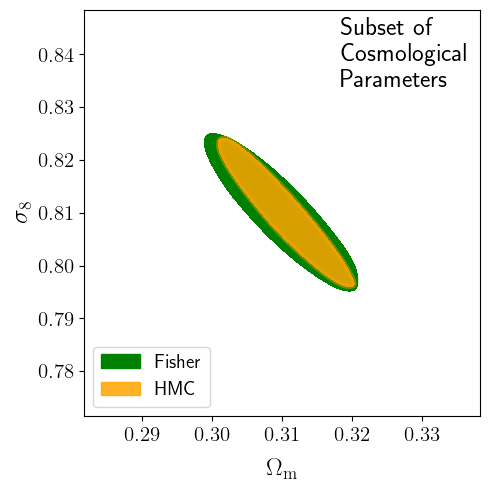

In [48]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_fisher, chain_hmc]
g.plot_2d(all_samples,'Om0', 'sigma8', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] )
        #   ,lims=[0.284, 0.346, 0.77, 0.9])  
g.add_legend([r'Fisher', r'HMC'], legend_loc='lower left', fontsize=14)
g.add_text('Subset of' + '\n' + 'Cosmological' + '\n' + 'Parameters', x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
# g.export(fname = 'cosmo_directcal.pdf')
# g.export(fname = '/mnt/home/spandey/ceph/GODMAX/notebooks/plots/Om_sig8_forecast_all_FINALSET.pdf')



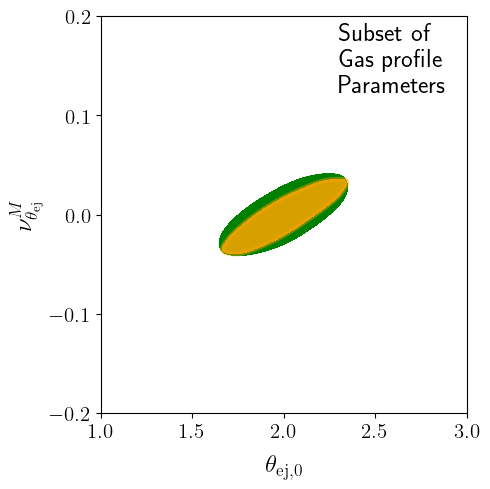

In [53]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_fisher, chain_hmc]
g.plot_2d(all_samples,'theta_ej_0', 'nu_theta_ej_M', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] 
           ,lims=[1, 3, -0.2, 0.2])  
# g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Subset of' + '\n' + 'Gas profile   ' + '\n' + 'Parameters',  x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
# g.export(fname = 'gas_prof_directcal.pdf')



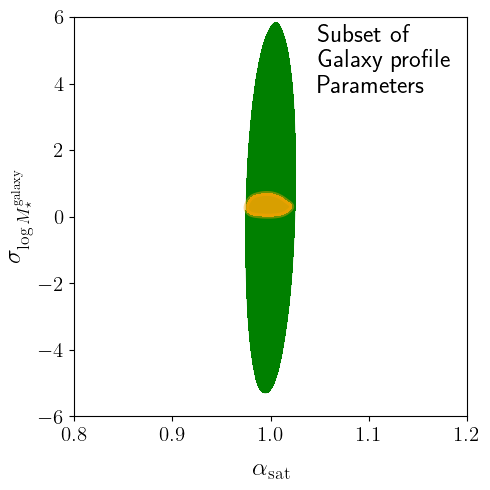

In [60]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_fisher, chain_hmc]
g.plot_2d(all_samples,'alphasat_Nsat', 'siglogMstar_Ncen', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','','']
          ,lims=[0.8, 1.2, -6, 6])    
g.add_text('Subset of' + '\n' 'Galaxy profile   ' + '\n' + 'Parameters',  x=0.62, y=0.89, fontsize=18, horizontalalignment='left')        
# g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
# g.export(fname = 'gal_prof_directcal.pdf')


